In [1]:
# 1.Import Required Libraries , numpy for numerical operations , pandas for dataset handling, matplotlib for visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 2. Sample Dataset creation -- we are creating unsupervised  dataset
data = {
    'Annual_Income': [15, 16, 17, 18, 19, 20, 70, 72, 75, 78, 80, 82],
    'Spending_Score': [39, 40, 42, 43, 44, 45, 20, 22, 25, 27, 30, 32]
}

df = pd.DataFrame(data)

In [4]:
df

,Annual_Income,Spending_Score
0,15,39
1,16,40
2,17,42
3,18,43
4,19,44
5,20,45
6,70,20
7,72,22
8,75,25
9,78,27


In [ ]:
# suppose this is the customer database and we are a company which gives credit cards ,now we have the data as their annual income and how much they spent,
# now based on this we have to decide who are those customers who can easily accept the card 
# and those customers will be our valuable customers , so here we would like to group them
# # by identifying which customers are similar

In [ ]:
# what the K measn will try to do ?
# K means will discover the hidden patterns in dataset and Group customers based on similarity in income and spending behavior

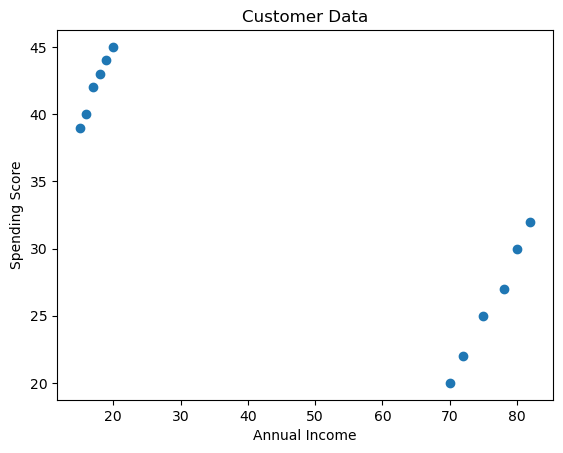

In [5]:
# 3. visualise the raw data
plt.scatter(df['Annual_Income'], df['Spending_Score'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")
plt.show()

In [6]:
# 4. Feature scaling =first of all we will comine all the numbers /values present in df into one array format and then we will go for feature scaling
X=df.values 

In [7]:
X

array([[15, 39],
       [16, 40],
       [17, 42],
       [18, 43],
       [19, 44],
       [20, 45],
       [70, 20],
       [72, 22],
       [75, 25],
       [78, 27],
       [80, 30],
       [82, 32]])

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled

array([[-1.07864855,  0.56246623],
       [-1.0447643 ,  0.67686614],
       [-1.01088006,  0.90566597],
       [-0.97699581,  1.02006588],
       [-0.94311156,  1.13446579],
       [-0.90922731,  1.2488657 ],
       [ 0.78498507, -1.61113209],
       [ 0.85275357, -1.38233227],
       [ 0.95440631, -1.03913253],
       [ 1.05605905, -0.81033271],
       [ 1.12382755, -0.46713297],
       [ 1.19159604, -0.23833315]])

In [ ]:
# why we do this feature scaling?
# K-Means uses Euclidean distance to find similarity
# Features with large scale dominate distance so algorithm will wrongly assume  that they are more important
# Scaling makes all features comparable

In [10]:
# 5. finding  K using Elbow Method
from sklearn.cluster import KMeans

wcss = []  # Within Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\annaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\annaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
C:\annaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\annaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads.

In [ ]:
# first we call k means clustering algorithm, then we select a range for "k" values, and for each k value we calculate WCSS
# WCSS (within cluster sum of squares) and its scikit learn implementation is by method inertia_
# WCSS stores one value per k , so we have given a blan list to upload all values.it measures how close compact the clusters are.
# WCSS is nothing but inertia_ 
# how the inertia_ is calculated?
# For each cluster:

# Take every data point in that cluster
# Measure its distance from the cluster’s centroid (uses euclidean distance)
# Square that distance
# Add them all together
# The final sum is inertia_

# Inertia Value Meaning---
# High value means Points are far from centroids (loose clusters)
# Low value means	Points are close to centroids (tight clusters)

# if k=1 then WCSS very high , if k=N then WCSS is 0
# k nad WCSS are inversaly proportional to each other

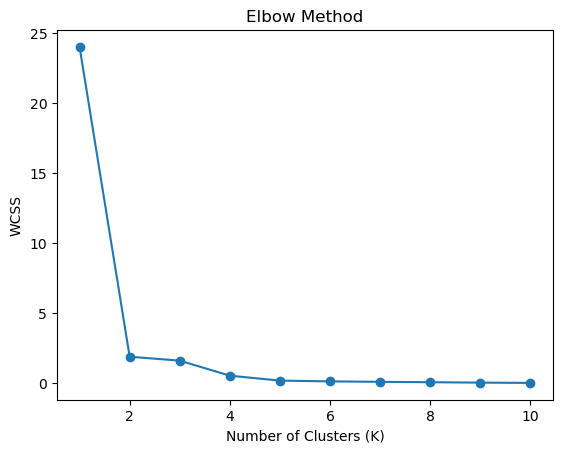

In [11]:
    # 6. plot the elbow curve
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
# the curve where it bend sharply that value of k is the optimum value or best value for k
# # so now we wil train the model with number of clusters =2

In [17]:
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

kmeans.fit(X_scaled)

C:\annaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=2, n_init=10, random_state=42)

In [ ]:
# we can see the hyper parameters , what are they?
# n_clusters = 	Number of clusters
# init = 	Smart centroid initialization
# max_iter= 	Max iterations
# n_init= 	Number of initializations
# random_state =	Reproducibility

In [19]:
print(df) # we can see clustered data

    Annual_Income  Spending_Score  Cluster
0              15              39        0
1              16              40        0
2              17              42        0
3              18              43        0
4              19              44        0
5              20              45        0
6              70              20        1
7              72              22        1
8              75              25        1
9              78              27        1
10             80              30        1
11             82              32        1


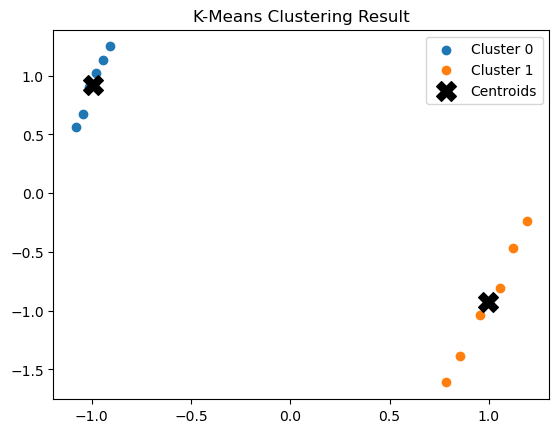

In [20]:
# 7. we can visualise clusters and centroids 
plt.scatter(
    X_scaled[labels == 0, 0],
    X_scaled[labels == 0, 1],
    label='Cluster 0'
)

plt.scatter(
    X_scaled[labels == 1, 0],
    X_scaled[labels == 1, 1],
    label='Cluster 1'
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.legend()
plt.title("K-Means Clustering Result")
plt.show()

In [29]:
# # lets check for somerandom points 
# suppose annual income is 99 and spending score is 50
new_point=[[99,50]]
predicted_cluster=kmeans.predict(new_point)
print("predicted cluster :",predicted_cluster)

predicted cluster : [1]
